In [1]:
import os
import pandas as pd
import sys
import numpy as np

from pathlib import Path

sys.path.insert(0, "..")

from src.viz import (
    plot_target_distribution,
    plot_hist,
    boxplot_by_target,
    top_corr_with_target,
    positive_rate_by_binary,
)

# 01. Read Dataset, Filter and Evaluate, EDA

## 1. Read Data

In [2]:
raw_path = "../data/asthma_disease_data.csv"
reports_dir = "../reports"
fig_dir = reports_dir + "/figures"

In [3]:
df = pd.read_csv(raw_path)
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,7421,43,1,0,2,29.059613,0,3.019854,6.119637,8.300960,...,3.125249,5.166032,0,1,0,0,0,1,1,Dr_Confid
2388,7422,18,1,0,1,20.740850,0,5.805180,4.386992,7.731192,...,1.132977,5.509502,0,0,0,1,1,0,1,Dr_Confid
2389,7423,54,0,3,2,37.079560,0,4.735169,8.214064,7.483521,...,1.685962,3.346877,1,0,1,1,0,1,1,Dr_Confid
2390,7424,46,1,0,2,23.444712,0,9.672637,7.362861,6.717272,...,3.481549,1.713274,0,1,1,0,1,1,0,Dr_Confid


## 2. Check Dataset Information

In [4]:
df.shape

(2392, 29)

2392 records and 29 features

In [5]:
# Check for imperative columns
required = ["PatientID", "Age", "BMI", "Diagnosis"]
missing_cols = [c for c in required if c not in df.columns]
missing_cols

[]

Fortunately, there are no records with missing key data

In [6]:
# Check for invalid age
if (df["Age"] < 0).any() or (df["Age"] > 120).any():
    print("There are records with invalid age!")

In [7]:
# Check for invalid BMI
if (df["BMI"] < 8).any() or (df["BMI"] > 80).any():
    print("There are records with invalid BMI!")

In [8]:
# Check for invalid diagnosis
unique_diagnosis = sorted(df["Diagnosis"].dropna().unique().tolist())

if not set(unique_diagnosis).issubset({0,1}):
         print("There are records with invalid diagnosis!")

## 3. Duplicates and Missing Values

In [9]:
duplicate_rows = int(df.duplicated().sum())
duplicate_rows

0

In [10]:
missingness = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missingness

PatientID                 0.0
Age                       0.0
Gender                    0.0
Ethnicity                 0.0
EducationLevel            0.0
BMI                       0.0
Smoking                   0.0
PhysicalActivity          0.0
DietQuality               0.0
SleepQuality              0.0
PollutionExposure         0.0
PollenExposure            0.0
DustExposure              0.0
PetAllergy                0.0
FamilyHistoryAsthma       0.0
HistoryOfAllergies        0.0
Eczema                    0.0
HayFever                  0.0
GastroesophagealReflux    0.0
LungFunctionFEV1          0.0
LungFunctionFVC           0.0
Wheezing                  0.0
ShortnessOfBreath         0.0
ChestTightness            0.0
Coughing                  0.0
NighttimeSymptoms         0.0
ExerciseInduced           0.0
Diagnosis                 0.0
DoctorInCharge            0.0
dtype: float64

No duplicated records and no missing values!

In [11]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy',
       'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever',
       'GastroesophagealReflux', 'LungFunctionFEV1', 'LungFunctionFVC',
       'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing',
       'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

## 4. Data Summary

In [12]:
summary_table = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_missing": df.isna().sum().values,
    "n_unique": df.nunique().values,
})

summary_table

,column,dtype,n_missing,n_unique
0,PatientID,int64,0,2392
1,Age,int64,0,75
2,Gender,int64,0,2
3,Ethnicity,int64,0,4
4,EducationLevel,int64,0,4
5,BMI,float64,0,2392
6,Smoking,int64,0,2
7,PhysicalActivity,float64,0,2392
8,DietQuality,float64,0,2392
9,SleepQuality,float64,0,2392


## 5. EDA

In [13]:
target = "Diagnosis"
y = df[target].astype(int)

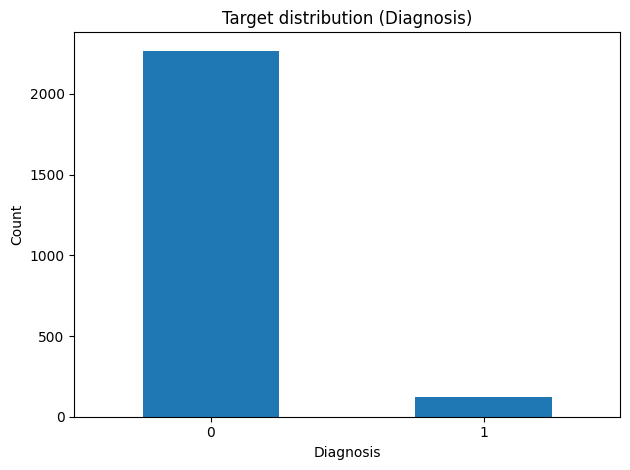

Saved: ../reports/figures/01_target_distribution.png


In [14]:
plot_target_distribution(y, 
    title="Target distribution (Diagnosis)", 
    save=fig_dir + "/01_target_distribution.png")

print("Saved:", fig_dir + "/01_target_distribution.png")

The positive bar is tiny next to the negative bar. That screams class imbalance. Accuracy will flatter bad models here, so we should judge models by PR curves, for example.

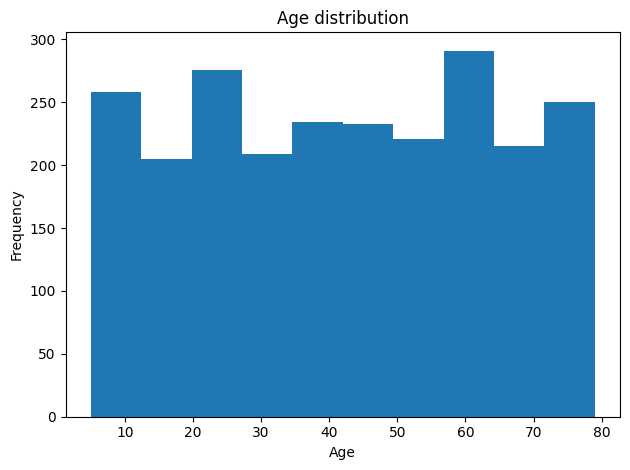

Saved: ../reports/figures/01_hist_age.png


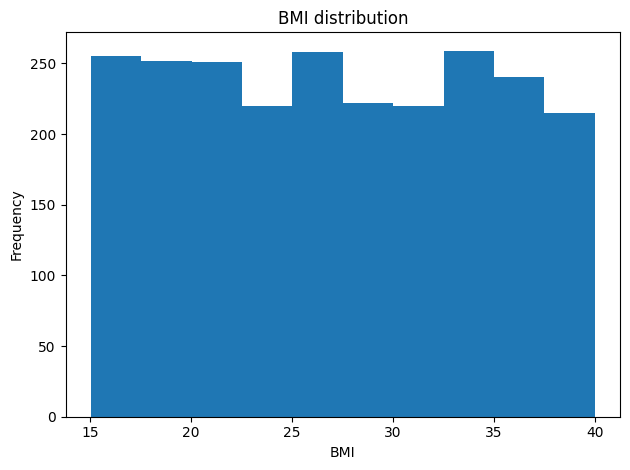

Saved: ../reports/figures/01_hist_bmi.png


In [15]:
for col in ["Age", "BMI"]:
    plot_hist(df, 
        col, 
        save=fig_dir + f"/01_hist_{col.lower()}.png")
    
    print("Saved:", fig_dir + f"/01_hist_{col.lower()}.png")

The age bars form a single hump without weird spikes or heavy tails. Nothing begs for log transforms. Age on its own likely won't separate classes, but it's a useful control and may matter through interactions (like age x activity, etc.). BMI looks clean and centered - no wild tails or clumps. It's safe to standardize and move on. By itself it probably won't split the classes; the value will come from combinations (BMI with exercise, reflux, or symptoms).

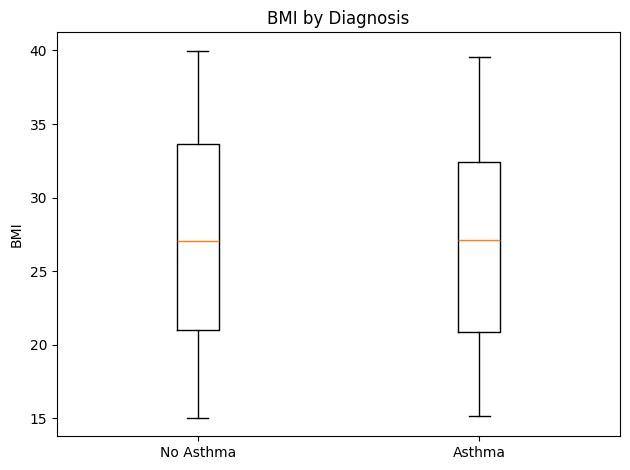

Saved: ../reports/figures/01_box_bmi_by_target.png


In [16]:
boxplot_by_target(df, 
        "BMI", 
        "Diagnosis",
        labels=("No Asthma", "Asthma"), 
        save=fig_dir + "/01_box_bmi_by_target.png")

print("Saved:", fig_dir + "/01_box_bmi_by_target.png")

The two boxes sit nearly on top of each other. That's the visual verdict: as a univariate signal, BMI is weak.

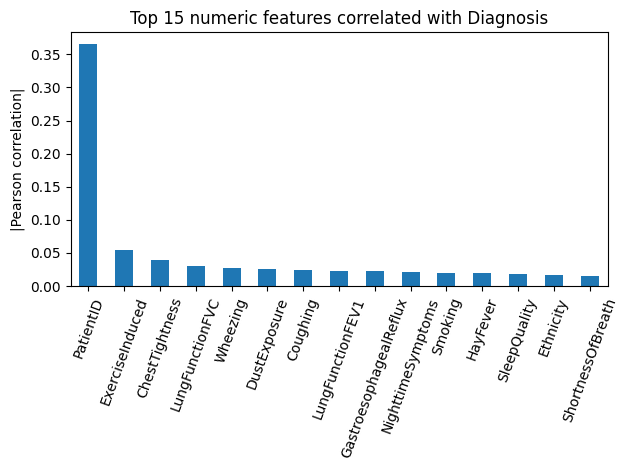

Saved: ../reports/figures/01_top_corr_with_target.png


In [17]:
corr_top = top_corr_with_target(df, 
    "Diagnosis",
    k=15, 
    save=fig_dir + "/01_top_corr_with_target.png")

print("Saved:", fig_dir + "/01_top_corr_with_target.png")

No single numeric feature carries strong linear signal (PatientID high - not enough)

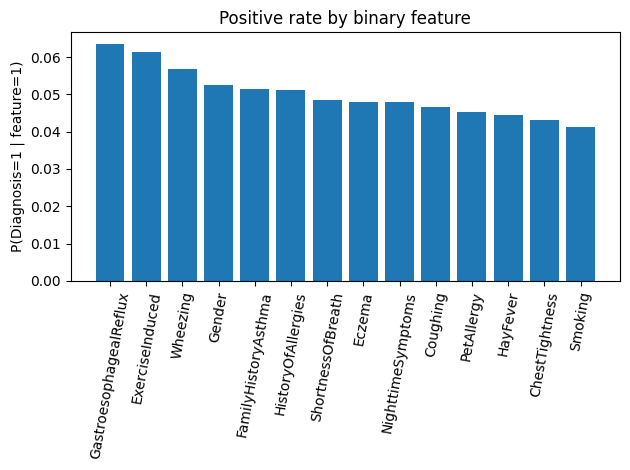

Saved: ../reports/figures/01_pos_rate_by_binary.png


In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

binary_like = []
for c in num_cols:
    if c == "Diagnosis":
        continue
        
    vals = df[c].dropna().unique()
    
    if set(vals).issubset({0, 1}):
        binary_like.append(c)

pos_rates = positive_rate_by_binary(df, 
        binary_like, 
        "Diagnosis", 
        top=15, 
        save=fig_dir + "/01_pos_rate_by_binary.png")

print("Saved:", fig_dir + "/01_pos_rate_by_binary.png")

The data looks tidy and consistent.